In [5]:
y_train

array([1, 1, 1, ..., 1, 1, 1], dtype=int8)

In [6]:
y_test


array([1, 1, 1, ..., 1, 1, 1], dtype=int8)

In [7]:
# y_true = np.argmax(y_test, axis=1) 

In [8]:
data['Label'].value_counts()

Label
1    74730
0     5345
Name: count, dtype: int64

In [11]:
np.count_nonzero(y_test == 1)

904

In [12]:
# np.count_nonzero(y_train == [1, 0])

In [13]:
# labels = np.argmax(y_test, axis=1)          # turns [1,0] -> 0; [0,1] -> 1
# unique, counts = np.unique(labels, return_counts=True)
# print(dict(zip(unique, counts)))

In [14]:
# labels = np.argmax(y_train, axis=1)          # turns [1,0] -> 0; [0,1] -> 1
# unique, counts = np.unique(labels, return_counts=True)
# print(dict(zip(unique, counts)))

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

def create_regularised_model(input_shape,
                             weight_decay=5e-5,
                             conv_dropout=0.3,
                             lstm_dropout=0.99):

    L2 = regularizers.l2(weight_decay)
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))               # (T, H, W, C)

    # --- Convolutional feature extractor ---
    for filters in (32, 64, 128):
        model.add(layers.TimeDistributed(
            layers.Conv2D(filters, (3, 3),
                          padding='same',
                          activation='relu',
                          kernel_regularizer=L2)))
        model.add(layers.TimeDistributed(layers.BatchNormalization()))
        model.add(layers.TimeDistributed(layers.MaxPooling2D()))
        # SpatialDropout2D zeroes entire feature maps ➜ stronger regularisation
        model.add(layers.TimeDistributed(layers.SpatialDropout2D(conv_dropout)))

    # Flatten the per-frame feature maps
    model.add(layers.TimeDistributed(layers.Flatten()))

    # --- Temporal modelling with Bi-LSTM ---
    model.add(layers.Bidirectional(
        layers.LSTM(128,
                    return_sequences=True,
                    dropout=lstm_dropout,          # input dropout
                    recurrent_dropout=lstm_dropout, # recurrent dropout
                    kernel_regularizer=L2)))

    # Dropout *between* the two LSTMs
    model.add(layers.Dropout(lstm_dropout))

    model.add(layers.Bidirectional(
        layers.LSTM(64,
                    dropout=lstm_dropout,
                    recurrent_dropout=lstm_dropout,
                    kernel_regularizer=L2)))

    # --- Classification head ---
    model.add(layers.Dense(64, activation='relu',
                           kernel_regularizer=L2))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(2, activation='softmax',
                           kernel_regularizer=L2))

    return model

# Create input shape based on the sequence length and pixel size
input_shape = (time_steps, 8, 8, 1)  # (timesteps, height, width, channels)
model = create_regularised_model(
            input_shape,
            weight_decay=7e-7,   # softer L2
            conv_dropout=0.3,   # weaker SpatialDropout2D
            lstm_dropout=0.10) 
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 5, 8, 8, 32)    │           320 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 5, 8, 8, 32)    │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 5, 4, 4, 32)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 5, 4, 4, 32)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 5, 4, 4, 64)    │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 5, 4, 4, 64)    │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 5, 2, 2, 64)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 5, 2, 2, 64)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 5, 2, 2, 128)   │        73,856 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 5, 2, 2, 128)   │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 5, 1, 1, 128)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 5, 1, 1, 128)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 5, 128)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 5, 256)         │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 529,474 (2.02 MB)

 Trainable params: 529,026 (2.02 MB)

 Non-trainable params: 448 (1.75 KB)


――――――  Fold 1/10  ――――――
Fold 1:  val_loss = 0.9173   val_acc = 0.3618
   ↳ New best model found (acc = 0.3618)

――――――  Fold 2/10  ――――――
Fold 2:  val_loss = 0.6347   val_acc = 0.7420
   ↳ New best model found (acc = 0.7420)

――――――  Fold 3/10  ――――――
Fold 3:  val_loss = 0.5488   val_acc = 0.7320

――――――  Fold 4/10  ――――――
Fold 4:  val_loss = 0.5208   val_acc = 0.7688
   ↳ New best model found (acc = 0.7688)

――――――  Fold 5/10  ――――――
Fold 5:  val_loss = 0.6875   val_acc = 0.7013

――――――  Fold 6/10  ――――――
Fold 6:  val_loss = 0.6457   val_acc = 0.6158

――――――  Fold 7/10  ――――――
Fold 7:  val_loss = 0.6941   val_acc = 0.5604

――――――  Fold 8/10  ――――――
Fold 8:  val_loss = 0.6931   val_acc = 0.5604

――――――  Fold 9/10  ――――――
Fold 9:  val_loss = 0.6937   val_acc = 0.5604

――――――  Fold 10/10  ――――――
Fold 10:  val_loss = 0.6687   val_acc = 0.6107

>>>>  CV results  <<<<
Accuracy : 0.6214 ± 0.1156
Loss     : 0.6704 ± 0.1010
X_test shape: (1491, 5, 8, 8, 1)
y_test shape before: (1491,)

>>>>

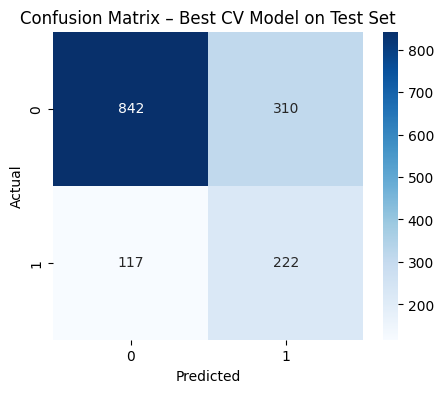

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import class_weight
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# 1. Load and preprocess data
file_path = "previous_dv0_withoutstraw_sipCAdded.xlsx"
data = pd.read_excel(file_path)

# Encode labels
le = LabelEncoder()
data["Label"] = le.fit_transform(data["Label"])
X = data.iloc[:, 1:65].values.astype("float32")
y = data["Label"].values.astype("int8")

# Identify majority/minority classes
from collections import Counter
freq = Counter(y)
majority_id, minority_id = max(freq, key=freq.get), min(freq, key=freq.get)

# Generate sequences with a dynamic stride
time_steps = 5
stride_major = 17
stride_minor = 1

X_seq, y_seq = [], []
i = 0
while i + time_steps < len(X):
    lbl_next = y[i + time_steps]
    X_seq.append(X[i : i + time_steps])
    y_seq.append(lbl_next)
    i += stride_major if lbl_next == majority_id else stride_minor

# Convert to numpy arrays
X_seq = np.array(X_seq, dtype="float32")
y_seq = np.array(y_seq, dtype="int8")

# Manual data split
train_ratio = 0.80
split_index = int(len(X_seq) * train_ratio)
X_train = X_seq[:split_index]
y_train = y_seq[:split_index]
X_test = X_seq[split_index:]
y_test = y_seq[split_index:]

# 2. Initialize cross-validation parameters
n_splits = 10
best_acc = -np.inf
best_wgt = None  # to store best-performing weights
acc_per_fold, loss_per_fold = [], []

skf = StratifiedKFold(n_splits=n_splits, shuffle=False)

# 3. Cross-validation loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f'\n――――――  Fold {fold}/{n_splits}  ――――――')

    # Split & reshape
    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

    X_fold_train = X_fold_train.reshape(-1, time_steps, 8, 8, 1)
    X_fold_val = X_fold_val.reshape(-1, time_steps, 8, 8, 1)

    # Convert labels to categorical
    y_fold_train = to_categorical(y_fold_train, num_classes=len(le.classes_))
    y_fold_val = to_categorical(y_fold_val, num_classes=len(le.classes_))

    # Create and compile the model
    model = create_regularised_model(
        input_shape=(time_steps, 8, 8, 1),
        weight_decay=5e-5,
        conv_dropout=0.3,
        lstm_dropout=0.10
    )
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Balanced class weights
    cw = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_fold_train),
            y=y_fold_train.argmax(axis=1))  # Assuming y_fold_train was categorical
    cw = dict(enumerate(cw))

    # Callbacks
    es = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=3,
            restore_best_weights=True, verbose=0)

    # Train the model
    model.fit(X_fold_train, y_fold_train,
              epochs=50, batch_size=32,
              validation_data=(X_fold_val, y_fold_val),
              class_weight=cw,
              callbacks=[es],
              verbose=0)

    # Evaluate the model
    loss, acc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    print(f'Fold {fold}:  val_loss = {loss:.4f}   val_acc = {acc:.4f}')

    acc_per_fold.append(acc)
    loss_per_fold.append(loss)

    if acc > best_acc:
        best_acc = acc
        best_wgt = model.get_weights()
        print(f'   ↳ New best model found (acc = {best_acc:.4f})')

# 4. Cross-validation summary
print('\n>>>>  CV results  <<<<')
print(f'Accuracy : {np.mean(acc_per_fold):.4f} ± {np.std(acc_per_fold):.4f}')
print(f'Loss     : {np.mean(loss_per_fold):.4f} ± {np.std(loss_per_fold):.4f}')

# 5. Reload the best model and evaluate on test data
best_model = create_regularised_model(
    input_shape=(time_steps, 8, 8, 1),
    weight_decay=5e-5,
    conv_dropout=0.3,
    lstm_dropout=0.10
)
best_model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])
best_model.set_weights(best_wgt)  # Load winning weights

# Prepare test-set tensors
X_test = X_test.reshape(-1, time_steps, 8, 8, 1)
y_test_cat = to_categorical(y_test, num_classes=len(le.classes_))
print("X_test shape:", X_test.shape)
print("y_test shape before:", y_test.shape)

# Evaluate on the test set
test_loss, test_acc = best_model.evaluate(X_test, y_test_cat, verbose=0)
print(f'\n>>>>  Test-set performance  <<<<')
print(f'Loss: {test_loss:.4f}   Accuracy: {test_acc:.4f}')

# Predictions
prob = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(prob, axis=1)  # Predicted class labels
y_true = np.argmax(y_test_cat, axis=1)

# Classic metrics
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print('\nDetailed metrics:')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-score  : {f1:.4f}')

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
labels = le.classes_  # Use the original class labels
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
             xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix – Best CV Model on Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [5]:
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
# auc  = roc_auc_score(y_true, prob[:,1])

print('\nDetailed metrics:')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-score  : {f1:.4f}')


Detailed metrics:
Precision : 0.4173
Recall    : 0.6549
F1-score  : 0.5098



――――――  Fold 1/10  ――――――
Fold 1:  val_loss = 0.4113   val_acc = 0.8646
   ↳ New best model found (acc = 0.8646)

――――――  Fold 2/10  ――――――
Fold 2:  val_loss = 0.3679   val_acc = 0.8576

――――――  Fold 3/10  ――――――
Fold 3:  val_loss = 0.6843   val_acc = 0.7292

――――――  Fold 4/10  ――――――
Fold 4:  val_loss = 0.6647   val_acc = 0.7213

――――――  Fold 5/10  ――――――
Fold 5:  val_loss = 0.4541   val_acc = 0.8502

――――――  Fold 6/10  ――――――
Fold 6:  val_loss = 0.7408   val_acc = 0.8467

――――――  Fold 7/10  ――――――
Fold 7:  val_loss = 0.3949   val_acc = 0.8780
   ↳ New best model found (acc = 0.8780)

――――――  Fold 8/10  ――――――
Fold 8:  val_loss = 0.6592   val_acc = 0.6725

――――――  Fold 9/10  ――――――
Fold 9:  val_loss = 0.4814   val_acc = 0.8362

――――――  Fold 10/10  ――――――
Fold 10:  val_loss = 0.4166   val_acc = 0.8502

>>>>  CV results  <<<<
Accuracy : 0.8106 ± 0.0696
Loss     : 0.5275 ± 0.1351
X_test shape: (719, 5, 8, 8, 1)
y_test shape before: (719,)

>>>>  Test-set performance  <<<<
Loss: 0.7154  

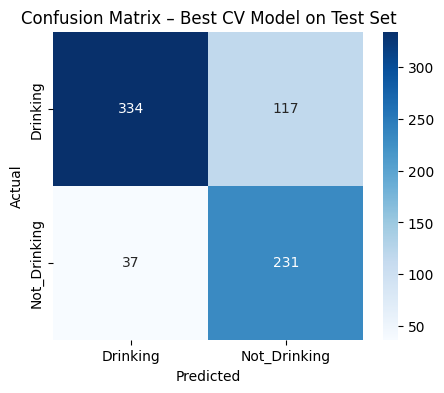

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import class_weight
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# 1. Load and preprocess data
file_path = "data_with_straw.xlsx"
data = pd.read_excel(file_path)

# Encode labels
le = LabelEncoder()
data["Label"] = le.fit_transform(data["Label"])
X = data.iloc[:, 1:65].values.astype("float32")
y = data["Label"].values.astype("int8")

# Identify majority/minority classes
from collections import Counter
freq = Counter(y)
majority_id, minority_id = max(freq, key=freq.get), min(freq, key=freq.get)

# Generate sequences with a dynamic stride
time_steps = 5
stride_major = 17
stride_minor = 1

X_seq, y_seq = [], []
i = 0
while i + time_steps < len(X):
    lbl_next = y[i + time_steps]
    X_seq.append(X[i : i + time_steps])
    y_seq.append(lbl_next)
    i += stride_major if lbl_next == majority_id else stride_minor

# Convert to numpy arrays
X_seq = np.array(X_seq, dtype="float32")
y_seq = np.array(y_seq, dtype="int8")

# Manual data split
train_ratio = 0.80
split_index = int(len(X_seq) * train_ratio)
X_train = X_seq[:split_index]
y_train = y_seq[:split_index]
X_test = X_seq[split_index:]
y_test = y_seq[split_index:]

# 2. Initialize cross-validation parameters
n_splits = 10
best_acc = -np.inf
best_wgt = None  # to store best-performing weights
acc_per_fold, loss_per_fold = [], []

skf = StratifiedKFold(n_splits=n_splits, shuffle=False)

# 3. Cross-validation loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f'\n――――――  Fold {fold}/{n_splits}  ――――――')

    # Split & reshape
    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

    X_fold_train = X_fold_train.reshape(-1, time_steps, 8, 8, 1)
    X_fold_val = X_fold_val.reshape(-1, time_steps, 8, 8, 1)

    # Convert labels to categorical
    y_fold_train = to_categorical(y_fold_train, num_classes=len(le.classes_))
    y_fold_val = to_categorical(y_fold_val, num_classes=len(le.classes_))

    # Create and compile the model
    model = create_regularised_model(
        input_shape=(time_steps, 8, 8, 1),
        weight_decay=5e-5,
        conv_dropout=0.3,
        lstm_dropout=0.10
    )
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Balanced class weights
    cw = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_fold_train),
            y=y_fold_train.argmax(axis=1))  # Assuming y_fold_train was categorical
    cw = dict(enumerate(cw))

    # Callbacks
    es = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=3,
            restore_best_weights=True, verbose=0)

    # Train the model
    model.fit(X_fold_train, y_fold_train,
              epochs=50, batch_size=32,
              validation_data=(X_fold_val, y_fold_val),
              class_weight=cw,
              callbacks=[es],
              verbose=0)

    # Evaluate the model
    loss, acc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    print(f'Fold {fold}:  val_loss = {loss:.4f}   val_acc = {acc:.4f}')

    acc_per_fold.append(acc)
    loss_per_fold.append(loss)

    if acc > best_acc:
        best_acc = acc
        best_wgt = model.get_weights()
        print(f'   ↳ New best model found (acc = {best_acc:.4f})')

# 4. Cross-validation summary
print('\n>>>>  CV results  <<<<')
print(f'Accuracy : {np.mean(acc_per_fold):.4f} ± {np.std(acc_per_fold):.4f}')
print(f'Loss     : {np.mean(loss_per_fold):.4f} ± {np.std(loss_per_fold):.4f}')

# 5. Reload the best model and evaluate on test data
best_model = create_regularised_model(
    input_shape=(time_steps, 8, 8, 1),
    weight_decay=5e-5,
    conv_dropout=0.3,
    lstm_dropout=0.10
)
best_model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])
best_model.set_weights(best_wgt)  # Load winning weights

# Prepare test-set tensors
X_test = X_test.reshape(-1, time_steps, 8, 8, 1)
y_test_cat = to_categorical(y_test, num_classes=len(le.classes_))
print("X_test shape:", X_test.shape)
print("y_test shape before:", y_test.shape)

# Evaluate on the test set
test_loss, test_acc = best_model.evaluate(X_test, y_test_cat, verbose=0)
print(f'\n>>>>  Test-set performance  <<<<')
print(f'Loss: {test_loss:.4f}   Accuracy: {test_acc:.4f}')

# Predictions
prob = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(prob, axis=1)  # Predicted class labels
y_true = np.argmax(y_test_cat, axis=1)

# Classic metrics
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print('\nDetailed metrics:')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-score  : {f1:.4f}')

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
labels = le.classes_  # Use the original class labels
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
             xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix – Best CV Model on Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [6]:
import numpy as np

# Parameters
time_steps = 5
zone_cols = [f"Zone_{i}" for i in range(64)]

X_seq = []
y_seq = []

for sip_id, group in data.groupby("sip_id"):
    gesture = group[zone_cols].values.astype("float32")  # (T_i, 64)
    label = group["Label"].iloc[0]                        # one label per gesture

    # Pad or truncate to fixed length
    if len(gesture) < time_steps:
        pad_width = time_steps - len(gesture)
        gesture = np.pad(gesture, ((0, pad_width), (0, 0)), mode='edge')
    elif len(gesture) > time_steps:
        gesture = gesture[:time_steps]

    gesture = gesture.reshape(time_steps, 8, 8, 1)
    X_seq.append(gesture)
    y_seq.append(label)

# Convert to arrays
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import to_categorical

# 1. Load data
file_path = "test.xlsx"  # Replace with your actual file path
data = pd.read_excel(file_path)

# 2. Encode labels
le = LabelEncoder()
data["Label"] = le.fit_transform(data["Label"])
zone_cols = [f"Zone_{i}" for i in range(64)]
time_steps = 5

# 3. Group by gestures (sip_id)
X_seq, y_seq = [], []
for sip_id, group in data.groupby("sip_id"):
    gesture = group[zone_cols].values.astype("float32")
    label = group["Label"].iloc[0]

    if len(gesture) < time_steps:
        pad_width = time_steps - len(gesture)
        gesture = np.pad(gesture, ((0, pad_width), (0, 0)), mode='edge')
    elif len(gesture) > time_steps:
        gesture = gesture[:time_steps]

    gesture = gesture.reshape(time_steps, 8, 8, 1)
    X_seq.append(gesture)
    y_seq.append(label)

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)
print("✅ Input shapes:")
print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)
print("Label distribution:", dict(zip(*np.unique(y_seq, return_counts=True))))

# 4. Split train/test
split_idx = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

# 5. Model definition
def create_regularised_model(input_shape, weight_decay=5e-5, conv_dropout=0.3, lstm_dropout=0.1):
    L2 = regularizers.l2(weight_decay)
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.TimeDistributed(layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=L2)),
        layers.TimeDistributed(layers.MaxPooling2D()),
        layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=L2)),
        layers.TimeDistributed(layers.MaxPooling2D()),
        layers.TimeDistributed(layers.Flatten()),
        layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=lstm_dropout)),
        layers.Bidirectional(layers.LSTM(64, dropout=lstm_dropout)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(len(le.classes_), activation='softmax')
    ])
    return model


✅ Input shapes:
X_seq shape: (2, 5, 8, 8, 1)
y_seq shape: (2,)
Label distribution: {np.int64(0): np.int64(1), np.int64(1): np.int64(1)}


In [10]:
# 1. Do NOT filter to label==1; keep all classes you want:
# df = df[df["Label"] == 1]  # REMOVE this filter

# 2. Prepare X, y for classification:
X, y = [], []
for _, g in df.groupby(seq_keys, sort=False):
    label = int(g["Label"].iloc[0])  # Use class label (assumed integer)
    X.append(g[feature_cols].to_numpy(np.float32))
    y.append(label)
y = np.array(y, dtype=np.int32)   # integer labels

# 3. train/val/test split etc same as before for X,y but labels are class ids

# 4. Dataset pipeline with padding is okay, just make sure y has shape () per instance:
output_sig = (
    tf.TensorSpec((None, 64), tf.float32),
    tf.TensorSpec((), tf.int32),
)

def make_ds(xs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(lambda: generator(xs, ys), output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    if BATCH == 1:
        return ds.repeat().batch(1)
    return ds.repeat().padded_batch(
        BATCH,
        padded_shapes=([None, 64], []),
        padding_values=(0.0, 0),
    )

train_ds = make_ds(X_train, y_train, shuffle=True)
val_ds = make_ds(X_val, y_val, shuffle=False)
test_ds = make_ds(X_test, y_test, shuffle=False)

# 5. Model output change for classification:
num_classes = len(np.unique(y))  # number of classes

inp = tf.keras.Input(shape=(None, 64))
x = TCN(nb_filters=128,
        kernel_size=2,
        dilations=[1,2,4,8,16,32],
        dropout_rate=0.1,
        return_sequences=False)(inp)
out = tf.keras.layers.Dense(num_classes, activation="softmax")(x)  # softmax for classification
model = tf.keras.Model(inp, out)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",  # use sparse labels
    metrics=["accuracy"],
)

model.summary()

# 6. Fit model as previously with train_ds, val_ds

# 7. For predictions use `model.predict()` and pick argmax as class prediction.

NameError: name 'df' is not defined